In [1]:
from floating_object import FloatingObjectSolver, SimConfig, NumericalParams, ObjectParams

config = SimConfig(
    num=NumericalParams(nx=400, nz=80, nt=4000),
    obj=ObjectParams(amplitude_cm=0.3, frequency=25.0),
    method="velocity",
)
solver = FloatingObjectSolver(config)
result = solver.run()
# result["eta_history"], result["time"], result["energy"], etc.

FloatingObjectSolver initialised
  Domain: 50.0×20.0 cm, Grid: 400×80
  Fr=1.0204, We=35.7347, Re=250000
  Object: 10.0cm wide, A=3.0mm, ω=25.0 rad/s
  Gravity wavelength λ ≈ 9.9 cm
  Method: velocity
  dt = 0.500 ms, 4000 steps
  LU prefactorisation: 0.145s

Running 4000 steps...
  Step     1 | t=0.0005s | max|η_free|=0.000106 | max|φ|=0.001841
  Step     2 | t=0.0010s | max|η_free|=0.000223 | max|φ|=0.002574
  Step     3 | t=0.0015s | max|η_free|=0.000339 | max|φ|=0.003252
  Step     4 | t=0.0020s | max|η_free|=0.000454 | max|φ|=0.004232
  Step     5 | t=0.0025s | max|η_free|=0.000566 | max|φ|=0.005162
  Step     6 | t=0.0030s | max|η_free|=0.000677 | max|φ|=0.006043
  Step     7 | t=0.0035s | max|η_free|=0.000784 | max|φ|=0.006877
  Step     8 | t=0.0040s | max|η_free|=0.000889 | max|φ|=0.007665
  Step     9 | t=0.0045s | max|η_free|=0.000992 | max|φ|=0.008408
  Step    10 | t=0.0050s | max|η_free|=0.001092 | max|φ|=0.009109
  Step   200 | t=0.1000s | max|η_free|=0.003198 | max|φ|=0

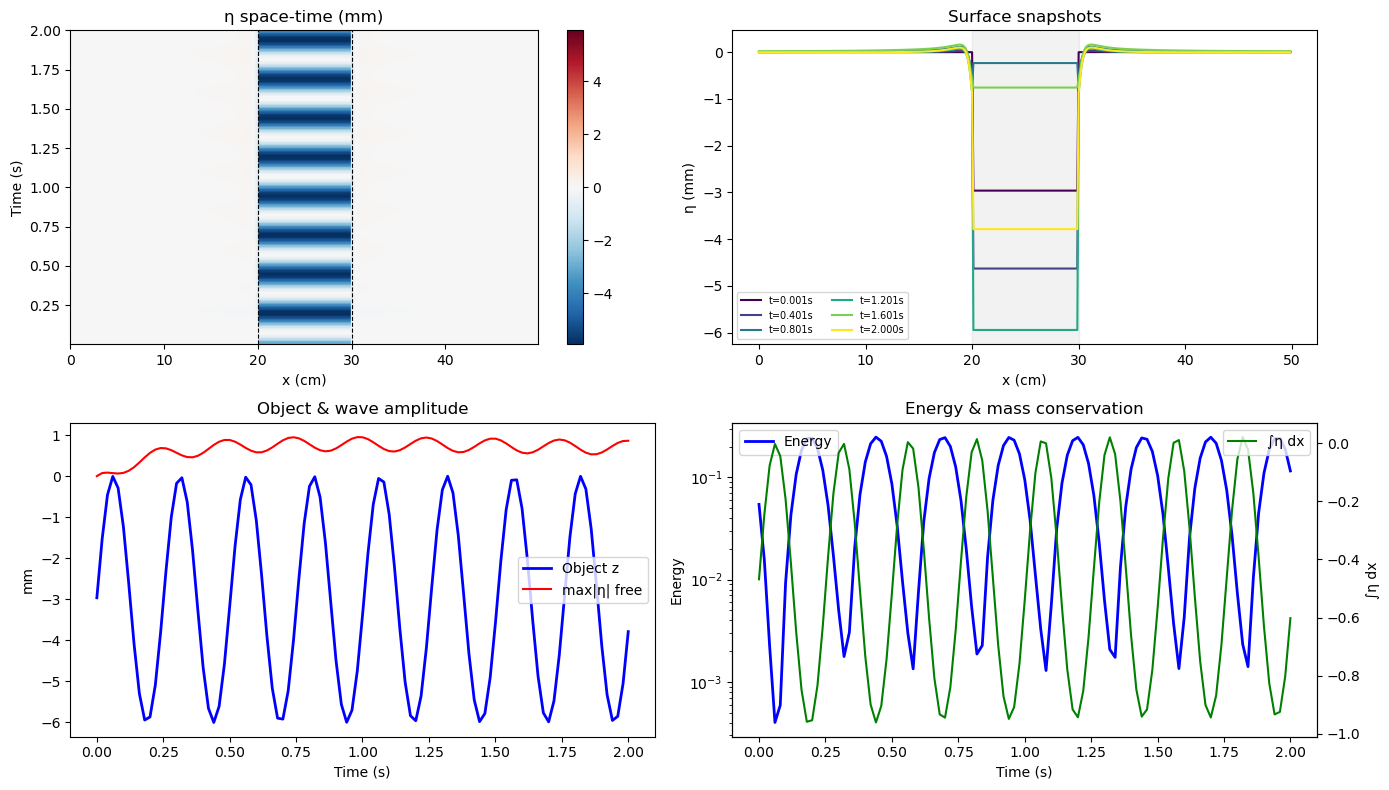

In [6]:
import matplotlib.pyplot as plt                                                                                                                                                                            
import numpy as np                                                                                                                                                                                         
                                                                                                                                                                                                            
x_cm = result["x"] * config.num.unit_length                                                                                                                                                                
t = result["time"]                                                                                                                                                                                         
eta_hist = np.array(result["eta_history"]) * config.num.unit_length * 10  # mm                                                                                                                             
obj_z_mm = result["object_z"] * config.num.unit_length * 10                                                                                                                                                
                                                                                                                                                                                                            
obj_left = (solver.xc_obj - solver.R_obj) * config.num.unit_length                                                                                                                                         
obj_right = (solver.xc_obj + solver.R_obj) * config.num.unit_length                                                                                                                                        
                                                                                                                                                                                                            
fig, axes = plt.subplots(2, 2, figsize=(14, 8))                                                                                                                                                            
                                                                                                                                                                                                            
# 1. Space-time diagram                                                                                                                                                                                    
ax = axes[0, 0]                                                                                                                                                                                          
vmax = np.percentile(np.abs(eta_hist), 99)                                                                                                                                                                 
im = ax.imshow(eta_hist, aspect="auto", origin="lower",                                                                                                                                                    
                extent=[x_cm[0], x_cm[-1], t[0], t[-1]],                                                                                                                                                    
                cmap="RdBu_r", vmin=-vmax, vmax=vmax)                                                                                                                                                       
ax.axvline(obj_left, color="k", ls="--", lw=0.8)                                                                                                                                                           
ax.axvline(obj_right, color="k", ls="--", lw=0.8)                                                                                                                                                          
ax.set(xlabel="x (cm)", ylabel="Time (s)", title="η space-time (mm)")                                                                                                                                      
plt.colorbar(im, ax=ax)                                                                                                                                                                                    
                                                                                                                                                                                                            
# 2. Surface snapshots                                                                                                                                                                                     
ax = axes[0, 1]                                                                                                                                                                                            
n_snap = 6                                                                                                                                                                                                 
idx = np.linspace(0, len(t) - 1, n_snap, dtype=int)                                                                                                                                                        
colors = plt.cm.viridis(np.linspace(0, 1, n_snap))                                                                                                                                                         
for i, c in zip(idx, colors):                                                                                                                                                                              
    ax.plot(x_cm, eta_hist[i], color=c, lw=1.5, label=f"t={t[i]:.3f}s")                                                                                                                                    
ax.axvspan(obj_left, obj_right, alpha=0.1, color="gray")                                                                                                                                                   
ax.set(xlabel="x (cm)", ylabel="η (mm)", title="Surface snapshots")                                                                                                                                        
ax.legend(fontsize=7, ncol=2)                                                                                                                                                                              
                                                                                                                                                                                                            
# 3. Object motion + max wave amplitude                                                                                                                                                                    
ax = axes[1, 0]                                                                                                                                                                                            
ax.plot(t, obj_z_mm, "b-", lw=2, label="Object z")                                                                                                                                                         
ax.plot(t, result["max_eta"] * config.num.unit_length * 10, "r-", lw=1.5, label="max|η| free")                                                                                                             
ax.set(xlabel="Time (s)", ylabel="mm", title="Object & wave amplitude")                                                                                                                                    
ax.legend()                                                                                                                                                                                                
                                                                                                                                                                                                            
# 4. Energy + mass                                                                                                                                                                                         
ax1 = axes[1, 1]                                                                                                                                                                                           
ax1.semilogy(t, result["energy"], "b-", lw=2, label="Energy")                                                                                                                                              
ax1.set(xlabel="Time (s)", ylabel="Energy", title="Energy & mass conservation")                                                                                                                            
ax1.legend(loc="upper left")                                                                                                                                                                               
ax2 = ax1.twinx()                                                                                                                                                                                          
ax2.plot(t, result["mass"], "g-", lw=1.5, label="∫η dx")                                                                                                                                                   
ax2.set_ylabel("∫η dx")                                                                                                                                                                                    
ax2.legend(loc="upper right")                                                                                                                                                                              
                                                                                                                                                                                                            
fig.tight_layout()                                                                                                                                                                                         
plt.show()  

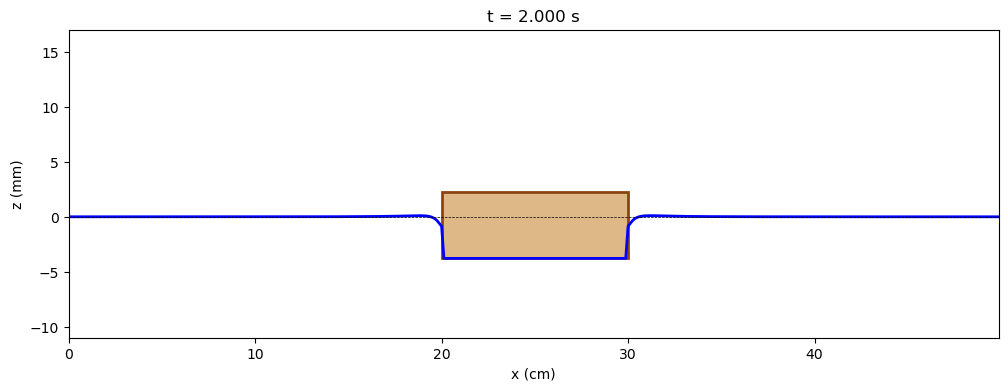

In [9]:
from matplotlib.animation import FuncAnimation, PillowWriter                                                                                                                                               
from matplotlib.patches import Rectangle                                                                                                                                                                   
import matplotlib.pyplot as plt                                                                                                                                                                            
import numpy as np                                                                                                                                                                                         
                                                                                                                                                                                                            
x_cm = result["x"] * config.num.unit_length                                                                                                                                                                
eta_mm = np.array(result["eta_history"]) * config.num.unit_length * 10                                                                                                                                     
obj_z_mm = result["object_z"] * config.num.unit_length * 10                                                                                                                                                
obj_left = (solver.xc_obj - solver.R_obj) * config.num.unit_length                                                                                                                                         
obj_w = 2 * solver.R_obj * config.num.unit_length                                                                                                                                                          
                                                                                                                                                                                                            
ymax = max(np.abs(eta_mm).max(), np.abs(obj_z_mm).max() + 5)                                                                                                                                               
                                                                                                                                                                                                            
fig, ax = plt.subplots(figsize=(12, 4))                                                                                                                                                                    
line, = ax.plot(x_cm, eta_mm[0], "b-", lw=2)              
rect = Rectangle((obj_left, obj_z_mm[0]), obj_w, 6, fc="burlywood", ec="saddlebrown", lw=2)                                                                                                                
ax.add_patch(rect)                                                                                                                                                                                         
ax.axhline(0, color="k", ls="--", lw=0.5)                                                                                                                                                                  
ax.set(xlim=[x_cm[0], x_cm[-1]], ylim=[-ymax, ymax + 6],                                                                                                                                                   
        xlabel="x (cm)", ylabel="z (mm)")                                                                                                                                                                   
title = ax.set_title("t = 0.000 s")                                                                                                                                                                        
                                                                                                                                                                                                            
def update(i):                                                                                                                                                                                             
    line.set_ydata(eta_mm[i])                                                                                                                                                                              
    rect.set_y(obj_z_mm[i])                                                                                                                                                                                
    title.set_text(f"t = {result['time'][i]:.3f} s")                                                                                                                                                       
    return line, rect                                                                                                                                                                                      
                                                                                                                                                                                                            
anim = FuncAnimation(fig, update, frames=len(result["time"]), interval=40, blit=True)                                                                                                                      
anim.save("./Outputs/floating_260330.gif", writer=PillowWriter(fps=25), dpi=150)                                                                                                                 
plt.show()  